# HVC Survey -- Scan Load and Reduction

Load raw dumps from `scripts/hvc/data/`, apply RFI flagging, outlier
dump filtering, frequency switching, per-cell gain calibration, and
LSR correction.

Data format:
- 1024 spectral channels, 3.2 MHz sample rate
- LO frequencies: f1=1419.86 MHz, f2=1421.14 MHz
- Per-cell calibration: 2 cal dumps + 32 obs dumps per pointing
- Non-integer galactic longitude (tessellated from l=120)

In [ ]:
import sys; sys.path.insert(0, '..')

from utils import flag_rfi_channels, flag_outlier_dumps, vlsr_correction

from pathlib import Path
from collections import defaultdict
import datetime as dt
import numpy as np
import pandas as pd
import astropy.coordinates as ac
import astropy.units as u_ast
import matplotlib.pyplot as plt

SAMPLE_RATE_HZ = 3.2e6
NFFT = 1024
HI_REST_MHZ = 1420.405
C_KMS = 299792.458

F1_MHZ = 1419.86
F2_MHZ = 1421.14

T_CAL_00 = 79.0  # K, pol 0
T_CAL_11 = 58.0  # K, pol 1

%matplotlib inline

## 1. Load raw dumps

In [2]:
DATA_DIR = Path('../../../../data/lab04/hvc')

records = []
for session_dir in sorted(DATA_DIR.glob('session_*')):
    for cell_dir in sorted(session_dir.glob('obs_*')) + sorted(session_dir.glob('cal_*')):
        for p in sorted(cell_dir.glob('*.npz')):
            with np.load(p, allow_pickle=True) as f:
                records.append({
                    'path': p,
                    'session': session_dir.name,
                    'target': str(f['target_name']),
                    'corr00': f['corr00'].astype(float),
                    'corr11': f['corr11'].astype(float),
                    'lo_mhz': float(f['lo_freq_mhz']),
                    'noise_on': bool(f['noise_on']),
                    'time': float(f['time']),
                    'alt': float(f['alt_deg']),
                    'az': float(f['az_deg']),
                    'ra': float(f['ra_deg']),
                    'dec': float(f['dec_deg']),
                })

N = len(records)

# Galactic coordinates from RA/Dec
for r in records:
    c = ac.SkyCoord(ra=r['ra'] * u_ast.deg, dec=r['dec'] * u_ast.deg, frame='icrs')
    r['gl'] = round(c.galactic.l.deg, 2)
    r['gb'] = round(c.galactic.b.deg)

sessions = sorted(set(r['session'] for r in records))
lo_unique = sorted(set(r['lo_mhz'] for r in records if not r['noise_on']))
n_cal = sum(1 for r in records if r['noise_on'])
n_sci = sum(1 for r in records if not r['noise_on'])

session_data = []
for s in sessions:
    n_cells = len(set((r['gl'], r['gb']) for r in records
                      if r['session'] == s and not r['noise_on']))
    n_dumps = sum(1 for r in records if r['session'] == s)
    if n_dumps > 0:
        session_data.append({'Session': s, 'Obs. Cells': n_cells, 'Dumps': n_dumps})
display(pd.DataFrame(session_data))

print(f'Total: {N} dumps ({n_sci} science, {n_cal} cal), '
      f'{len(sessions)} sessions, LO: {lo_unique}')

,Session,Obs. Cells,Dumps
0,session_001,3,76


Total: 76 dumps (68 science, 8 cal), 1 sessions, LO: [1419.86, 1421.14]


## 2. fftshift + RFI flagging

In [3]:
DC_BIN = NFFT // 2
f_bb_mhz = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1.0 / SAMPLE_RATE_HZ)) / 1e6
df_khz = SAMPLE_RATE_HZ / NFFT / 1e3

for r in records:
    r['corr00'] = np.fft.fftshift(r['corr00'])
    r['corr11'] = np.fft.fftshift(r['corr11'])
    r['stokes_I'] = r['corr00'] + r['corr11']

RFI_WINDOW = 15
RFI_SIGMA = 10.0
n_flagged = sum(flag_rfi_channels(r['stokes_I'], RFI_WINDOW, RFI_SIGMA)
                for r in records)

print(f'Baseband: [{f_bb_mhz[0]:.3f}, {f_bb_mhz[-1]:.3f}] MHz, '
      f'dnu = {df_khz:.2f} kHz')
print(f'RFI flagged: {n_flagged} samples across {N} dumps')

Baseband: [-1.600, 1.598] MHz, dnu = 2.08 kHz
RFI flagged: 205 samples across 76 dumps


## 3. Outlier dump filter

In [4]:
outlier_records = flag_outlier_dumps(records, 0.10, 0.20)
N = len(records)
print(f'Outlier dump filter: removed {len(outlier_records)} dumps')
print(f'Remaining: {N} dumps')

Outlier dump filter: removed 0 dumps
Remaining: 76 dumps


## 4. Frequency switching (R)

Pair dumps at f1 and f2, compute R = (I_f1 - I_f2) / I_f2.

In [5]:
EDGE_TRIM_MHZ = 0.256

lo1, lo2 = F1_MHZ, F2_MHZ
f_sky = lo1 + f_bb_mhz
f_sky_2 = lo2 + f_bb_mhz
f_overlap_lo = max(f_sky[0], f_sky_2[0]) + EDGE_TRIM_MHZ
f_overlap_hi = min(f_sky[-1], f_sky_2[-1]) - EDGE_TRIM_MHZ
overlap_mask = (f_sky >= f_overlap_lo) & (f_sky <= f_overlap_hi)
f_overlap = f_sky[overlap_mask]
v_overlap = C_KMS * (1 - f_overlap / HI_REST_MHZ)
dv_kms = np.abs(np.median(np.diff(v_overlap)))

print(f'LO pair: ({lo1}, {lo2}) MHz')
print(f'Overlap: [{f_overlap_lo:.2f}, {f_overlap_hi:.2f}] MHz')
print(f'Velocity (topo): [{v_overlap[-1]:.0f}, {v_overlap[0]:.0f}] km/s')
print(f'dv = {dv_kms:.3f} km/s per channel')

# Frequency-switched R per (session, cell)
from utils import compute_R_for_dumps

all_pointings = sorted(set((r['gl'], r['gb']) for r in records
                           if r['gl'] is not None))

cell_results = {}
for gl, gb in all_pointings:
    sci_dumps = [r for r in records
                 if r['gl'] == gl and r['gb'] == gb and not r['noise_on']]
    for dr in sessions:
        dr_dumps = [r for r in sci_dumps if r['session'] == dr]
        result = compute_R_for_dumps(dr_dumps, lo1, lo2, overlap_mask, v_overlap)
        if result is not None:
            cell_results[(dr, gl, gb)] = result

print(f'\nPer-session R: {len(cell_results)} (session, cell) entries')
for dr in sessions:
    n = sum(1 for k in cell_results if k[0] == dr)
    if n > 0:
        print(f'  {dr}: {n} cells')

LO pair: (1419.86, 1421.14) MHz
Overlap: [1419.80, 1421.20] MHz
Velocity (topo): [-168, 128] km/s
dv = 0.440 km/s per channel

Per-session R: 3 (session, cell) entries
  session_001: 3 cells


/home/ikaros/projects/ay-121/labs/04/notebooks/hvc/../utils/freqswitch.py:107: RuntimeWarning: Mean of empty slice
  R_mean = np.nanmean(R_cat, axis=0)


## 5. Per-cell gain calibration

Each cell has its own cal-on/cal-off pair. Compute gain per cell,
then T_sys = P_off / gain. Convert R -> T_B = R * T_sys.

In [6]:
dc_mask = np.ones(NFFT, dtype=bool)
dc_mask[DC_BIN - 2 : DC_BIN + 1] = False

# Per-cell gain: use cal dumps at same (gl, gb) as the science dumps.
# Unlike the main survey (1 cal per session), HVC has cal per cell.
cell_gains = {}  # (session, gl, gb) -> {'gain_00': float, 'gain_11': float}

cal_dumps = defaultdict(list)
for r in records:
    if r['noise_on']:
        cal_dumps[(r['session'], r['gl'], r['gb'])].append(r)

obs_dumps_by_cell = defaultdict(list)
for r in records:
    if not r['noise_on']:
        obs_dumps_by_cell[(r['session'], r['gl'], r['gb'])].append(r)

for key in cal_dumps:
    cals = cal_dumps[key]
    obs = obs_dumps_by_cell.get(key, [])
    if not cals or not obs:
        continue

    P_on_00 = np.nanmean([c['corr00'] for c in cals], axis=0)
    P_on_11 = np.nanmean([c['corr11'] for c in cals], axis=0)
    P_off_00 = np.nanmean([o['corr00'] for o in obs], axis=0)
    P_off_11 = np.nanmean([o['corr11'] for o in obs], axis=0)

    diff_00 = P_on_00 - P_off_00
    diff_11 = P_on_11 - P_off_11
    diff_00[diff_00 <= 0] = np.nan
    diff_11[diff_11 <= 0] = np.nan

    cell_gains[key] = {
        'gain_00': np.nanmedian(diff_00[dc_mask] / T_CAL_00),
        'gain_11': np.nanmedian(diff_11[dc_mask] / T_CAL_11),
    }

print(f'Gain computed for {len(cell_gains)} (session, cell) entries')

# Convert per-session R -> T_B
cell_results_TB = {}

for (dr, gl, gb), res in cell_results.items():
    g = cell_gains.get((dr, gl, gb))
    obs = obs_dumps_by_cell.get((dr, gl, gb), [])
    if g is None or not obs:
        continue

    mean_P00 = np.mean([np.nanmedian(o['corr00'][dc_mask]) for o in obs])
    mean_P11 = np.mean([np.nanmedian(o['corr11'][dc_mask]) for o in obs])
    T_sys_00 = mean_P00 / g['gain_00']
    T_sys_11 = mean_P11 / g['gain_11']
    T_sys = (T_sys_00 + T_sys_11) / 2.0

    cell_results_TB[(dr, gl, gb)] = {
        'T_B_overlap': res['R_overlap'] * T_sys,
        'R_overlap': res['R_overlap'],
        'T_sys': T_sys,
        'gain_00': g['gain_00'],
        'gain_11': g['gain_11'],
        'n_pairs': res['n_pairs'],
    }

print(f'Calibrated {len(cell_results_TB)} (session, cell) entries')

# Gain summary
gain_rows = []
for (dr, gl, gb), v in sorted(cell_results_TB.items()):
    gain_rows.append({
        'session': dr, 'gl': gl, 'gb': gb,
        'gain_00': v['gain_00'], 'gain_11': v['gain_11'],
        'T_sys': v['T_sys'],
    })
gain_df = pd.DataFrame(gain_rows)
if len(gain_df):
    print(f'\nGain stats:')
    print(f'  gain_00: {gain_df["gain_00"].median():.2f} (median), '
          f'range [{gain_df["gain_00"].min():.2f}, {gain_df["gain_00"].max():.2f}]')
    print(f'  gain_11: {gain_df["gain_11"].median():.2f} (median), '
          f'range [{gain_df["gain_11"].min():.2f}, {gain_df["gain_11"].max():.2f}]')
    print(f'  T_sys:   {gain_df["T_sys"].median():.0f} K (median), '
          f'range [{gain_df["T_sys"].min():.0f}, {gain_df["T_sys"].max():.0f}] K')

Gain computed for 3 (session, cell) entries
Calibrated 3 (session, cell) entries

Gain stats:
  gain_00: 0.57 (median), range [0.56, 0.60]
  gain_11: 9.32 (median), range [8.93, 9.40]
  T_sys:   778 K (median), range [736, 781] K


## 6. LSR correction and combine sessions

In [7]:
print('Computing LSR corrections...')
cell_dr_groups = defaultdict(list)
for r in records:
    if r.get('gl') is None or r['noise_on']:
        continue
    cell_dr_groups[(r['session'], r['gl'], r['gb'])].append(r)

session_cell_vcorr = {}
for key, group in cell_dr_groups.items():
    r0 = group[0]
    mean_t = np.mean([r['time'] for r in group])
    session_cell_vcorr[key] = vlsr_correction(r0['ra'], r0['dec'], mean_t)

sci_vcorr = list(session_cell_vcorr.values())
mean_vcorr = np.mean(sci_vcorr) if sci_vcorr else 0.0
v_lsr_overlap = v_overlap + mean_vcorr

if sci_vcorr:
    print(f'v_corr range: {min(sci_vcorr):.2f} to {max(sci_vcorr):.2f} km/s '
          f'(mean {mean_vcorr:.2f})')
    print(f'Velocity (LSR): [{v_lsr_overlap[-1]:.0f}, {v_lsr_overlap[0]:.0f}] km/s')
else:
    print('No science dumps -- skipping LSR correction')

# Combine per-session T_B onto common LSR grid (flip for np.interp)
cell_combined = {}
cell_sessions = defaultdict(list)
for (dr, gl, gb) in cell_results_TB:
    cell_sessions[(gl, gb)].append(dr)

v_lsr_inc = v_lsr_overlap[::-1]

for (gl, gb), dr_list in cell_sessions.items():
    TB_all = []
    R_all = []
    tsys_all = []
    npairs_total = 0

    for dr in dr_list:
        res = cell_results_TB[(dr, gl, gb)]
        v_corr = session_cell_vcorr.get((dr, gl, gb), 0.0)
        v_shifted = v_overlap + v_corr

        TB_interp = np.interp(v_lsr_inc, v_shifted[::-1],
                              res['T_B_overlap'][::-1],
                              left=np.nan, right=np.nan)[::-1]
        R_interp = np.interp(v_lsr_inc, v_shifted[::-1],
                             res['R_overlap'][::-1],
                             left=np.nan, right=np.nan)[::-1]
        TB_all.append(TB_interp)
        R_all.append(R_interp)
        tsys_all.append(res['T_sys'])
        npairs_total += res['n_pairs']

    cell_combined[(gl, gb)] = {
        'T_B': np.nanmean(TB_all, axis=0),
        'R': np.nanmean(R_all, axis=0),
        'T_sys': np.mean(tsys_all),
        'n_pairs': npairs_total,
    }

n_valid = sum(1 for v in cell_combined.values()
              if np.count_nonzero(np.isfinite(v['T_B'])) >= 8)
print(f'Combined (LSR): {len(cell_combined)} cells ({n_valid} with >=8 valid channels)')

Computing LSR corrections...
v_corr range: 6.19 to 9.11 km/s (mean 7.65)
Velocity (LSR): [-160, 136] km/s
Combined (LSR): 3 cells (3 with >=8 valid channels)


/tmp/ipykernel_39126/675278835.py:56: RuntimeWarning: Mean of empty slice
  'T_B': np.nanmean(TB_all, axis=0),
/tmp/ipykernel_39126/675278835.py:57: RuntimeWarning: Mean of empty slice
  'R': np.nanmean(R_all, axis=0),


## 7. Reference spectrum and gain diagnostics

Plot a reference R spectrum (brightest cell) and per-cell gain.

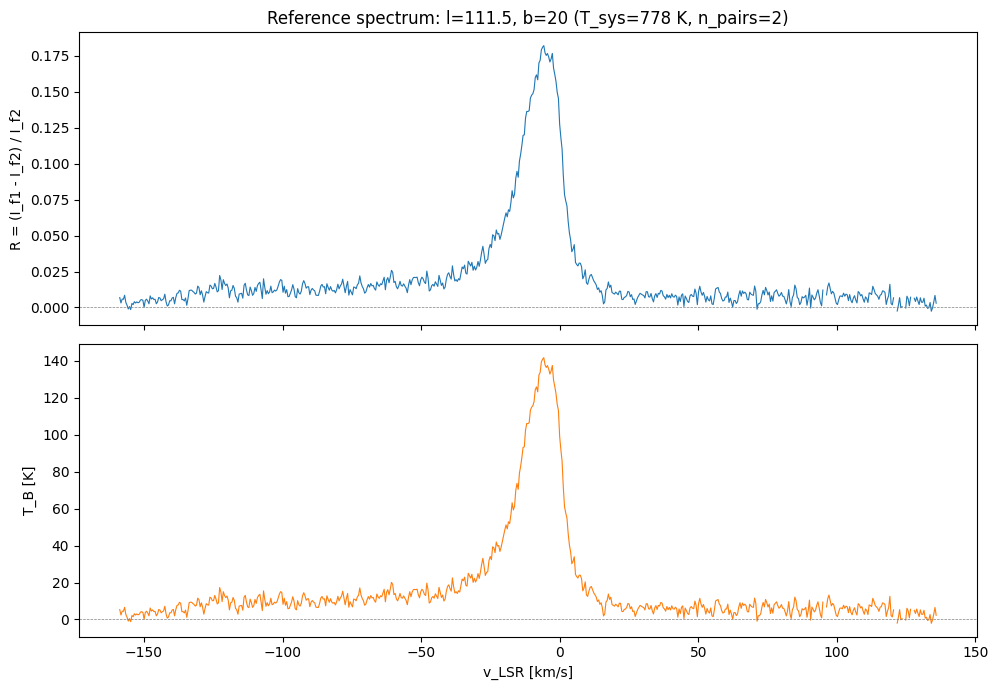

Peak R = 0.1822, Peak T_B = 141.8 K


In [8]:
# Find the brightest cell (highest peak R) for a reference spectrum
best_key = None
best_peak = -np.inf
for (gl, gb), v in cell_combined.items():
    peak = np.nanmax(np.abs(v['R']))
    if peak > best_peak:
        best_peak = peak
        best_key = (gl, gb)

if best_key is not None:
    ref = cell_combined[best_key]

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    # R spectrum
    ax = axes[0]
    ax.plot(v_lsr_overlap, ref['R'], lw=0.8, color='C0')
    ax.axhline(0, color='gray', ls='--', lw=0.5)
    ax.set_ylabel('R = (I_f1 - I_f2) / I_f2')
    ax.set_title(f'Reference spectrum: l={best_key[0]:.1f}, b={best_key[1]} '
                 f'(T_sys={ref["T_sys"]:.0f} K, n_pairs={ref["n_pairs"]})')

    # T_B spectrum
    ax = axes[1]
    ax.plot(v_lsr_overlap, ref['T_B'], lw=0.8, color='C1')
    ax.axhline(0, color='gray', ls='--', lw=0.5)
    ax.set_ylabel('T_B [K]')
    ax.set_xlabel('v_LSR [km/s]')

    fig.tight_layout()
    plt.show()

    print(f'Peak R = {best_peak:.4f}, '
          f'Peak T_B = {np.nanmax(ref["T_B"]):.1f} K')
else:
    print('No cells to plot')

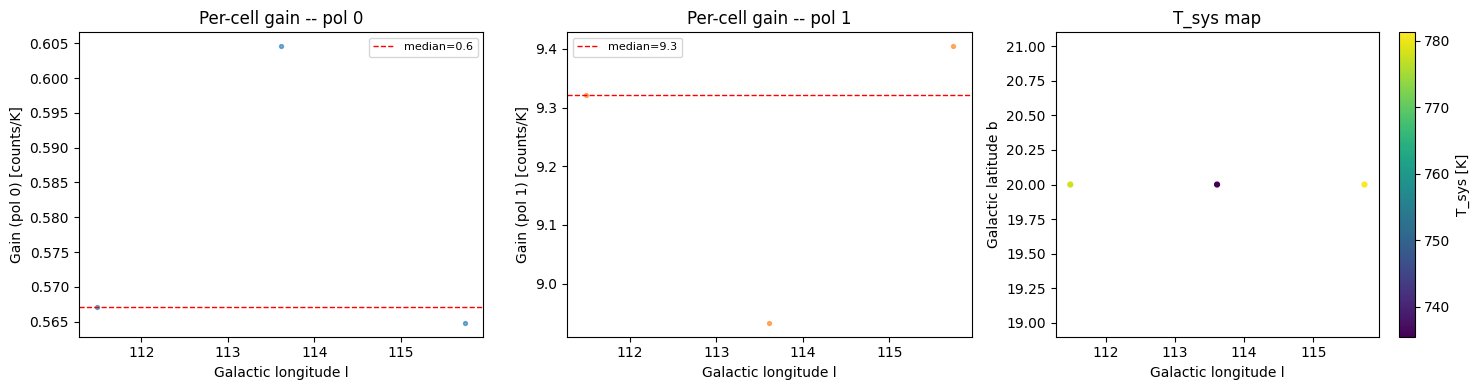

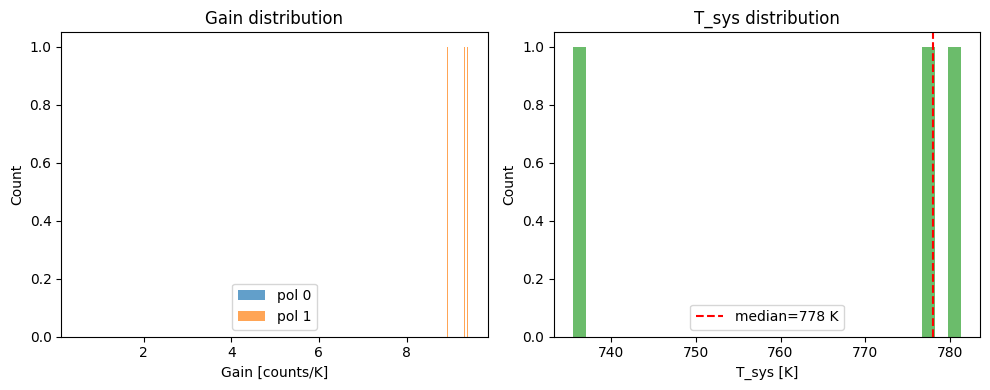

In [9]:
# Per-cell gain diagnostic
if len(gain_df):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Gain per cell (pol 0)
    ax = axes[0]
    ax.scatter(gain_df['gl'], gain_df['gain_00'], s=8, alpha=0.6)
    ax.axhline(gain_df['gain_00'].median(), color='red', ls='--', lw=1,
               label=f'median={gain_df["gain_00"].median():.1f}')
    ax.set_xlabel('Galactic longitude l')
    ax.set_ylabel('Gain (pol 0) [counts/K]')
    ax.set_title('Per-cell gain -- pol 0')
    ax.legend(fontsize=8)

    # Gain per cell (pol 1)
    ax = axes[1]
    ax.scatter(gain_df['gl'], gain_df['gain_11'], s=8, alpha=0.6, color='C1')
    ax.axhline(gain_df['gain_11'].median(), color='red', ls='--', lw=1,
               label=f'median={gain_df["gain_11"].median():.1f}')
    ax.set_xlabel('Galactic longitude l')
    ax.set_ylabel('Gain (pol 1) [counts/K]')
    ax.set_title('Per-cell gain -- pol 1')
    ax.legend(fontsize=8)

    # T_sys per cell
    ax = axes[2]
    sc = ax.scatter(gain_df['gl'], gain_df['gb'], c=gain_df['T_sys'],
                    s=12, cmap='viridis')
    plt.colorbar(sc, ax=ax, label='T_sys [K]')
    ax.set_xlabel('Galactic longitude l')
    ax.set_ylabel('Galactic latitude b')
    ax.set_title('T_sys map')

    fig.tight_layout()
    plt.show()

    # Gain stability histogram
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    ax = axes[0]
    ax.hist(gain_df['gain_00'], bins=30, alpha=0.7, label='pol 0')
    ax.hist(gain_df['gain_11'], bins=30, alpha=0.7, label='pol 1')
    ax.set_xlabel('Gain [counts/K]')
    ax.set_ylabel('Count')
    ax.set_title('Gain distribution')
    ax.legend()

    ax = axes[1]
    ax.hist(gain_df['T_sys'], bins=30, alpha=0.7, color='C2')
    ax.axvline(gain_df['T_sys'].median(), color='red', ls='--',
               label=f'median={gain_df["T_sys"].median():.0f} K')
    ax.set_xlabel('T_sys [K]')
    ax.set_ylabel('Count')
    ax.set_title('T_sys distribution')
    ax.legend()

    fig.tight_layout()
    plt.show()
else:
    print('No gain data to plot')